In [ ]:
!nvidia-smi -l 1

In [ ]:
import sys
sys.path.append('/home/galk/LanguageDynamics/src') 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm

import os
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.distributions.kl import kl_divergence
from torch.distributions.multivariate_normal import MultivariateNormal
# from datasets import load_dataset
from datetime import datetime

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

from importlib import reload

models_path = '/home/galk/LanguageDynamics/models/linguistic_flip_flop'

In [ ]:
def compute_and_plot_sliding_window_metrics(probabilities, window_size):
    """
    Computes and plots the sliding window mean log-probability and perplexity.
    
    Args:
        probabilities (list or np.ndarray): 1D array of actual token probabilities.
        window_size (int): The size of the sliding window.
        
    Returns:
        tuple: (moving_mean_log_probs, sliding_perplexity)
    """
    probs = np.array(probabilities)
    
    # 1. Compute Mean Log-Probability (Log-Perplexity)
    log_probs = np.log(probs + 1e-12)
    window = np.ones(window_size) / window_size
    moving_mean_log_probs = np.convolve(log_probs, window, mode='valid')
    
    # 2. Compute Perplexity
    # Standard perplexity is the exponent of the negative mean log-probability
    sliding_perplexity = np.exp(-moving_mean_log_probs)
    
    # --- Plotting ---
    # Create a figure with two subplots sharing the X-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    x_axis = np.arange(window_size - 1, len(probs))
    
    # Top Plot: Mean Log-Probability
    ax1.plot(x_axis, moving_mean_log_probs, color='teal', linewidth=2, label=f'Mean Log-Prob (Window={window_size})')
    ax1.set_title('Sliding Window Mean Log-Probability')
    ax1.set_ylabel('Mean Log-Probability')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()
    
    # Bottom Plot: Perplexity
    ax2.plot(x_axis, sliding_perplexity, color='coral', linewidth=2, label=f'Perplexity (Window={window_size})')
    ax2.set_title('Sliding Window Perplexity')
    ax2.set_xlabel('Token Sequence Index (End of Window)')
    ax2.set_ylabel('Perplexity')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return moving_mean_log_probs, sliding_perplexity

In [ ]:
def plot_sliding_window_metrics(sliding_log_probs, sliding_perplexity, window_size):
    # 1. Convert to numpy arrays to handle both PyTorch tensors and lists safely
    log_probs = np.array(sliding_log_probs)
    perplexities = np.array(sliding_perplexity)
    
    # Ensure shapes match
    if log_probs.shape != perplexities.shape:
        raise ValueError(f"Shape mismatch: log_probs {log_probs.shape} != perplexities {perplexities.shape}")
    
    B, T = log_probs.shape
    
    # 2. Setup Figure and Axes
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Assuming T is the exact number of sliding windows computed
    x_axis = np.arange(window_size - 1, window_size - 1 + T)
    
    # Generate distinct colors for each batch item using the viridis colormap
    colors = cm.viridis(np.linspace(0, 0.9, B))
    
    # 3. Plot each sequence in the batch
    for b in range(B):
        label_str = f'Seq {b}'
        
        # Top Plot: Mean Log-Probability
        ax1.plot(x_axis, log_probs[b], color=colors[b], linewidth=2, alpha=0.8, label=label_str)
        
        # Bottom Plot: Perplexity
        ax2.plot(x_axis, perplexities[b], color=colors[b], linewidth=2, alpha=0.8, label=label_str)

    # 4. Format Axes
    ax1.set_title('Sliding Window Mean Log-Probability')
    ax1.set_ylabel('Mean Log-Probability')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    ax2.set_title('Sliding Window Perplexity')
    ax2.set_xlabel('Token Sequence Index (End of Window)')
    ax2.set_ylabel('Perplexity')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    # 5. Handle Legend (Place it outside the plot if the batch is large to avoid clutter)
    if B <= 10:
        ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.tight_layout()
    plt.show()

In [ ]:
def nucleus_sampling(logits, top_p=0.9):
    """
    Applies top-p (nucleus) sampling to logits of any shape (e.g., [B, T, V]).
    """
    # Clone to avoid mutating the original input logits tensor in-place
    logits = logits.clone()
    
    # Sort along the vocabulary dimension (dim=-1)
    sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
    cumulative_probs = torch.softmax(sorted_logits, dim=-1).cumsum(dim=-1)

    # Create a mask for tokens exceeding the top_p threshold
    sorted_indices_to_remove = cumulative_probs > top_p

    # Shift the mask to the right. 
    # The ellipsis (...) safely handles the B and T dimensions.
    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
    sorted_indices_to_remove[..., 0] = 0

    # Map the mask back to the original logits shape using a blank boolean tensor
    indices_to_remove = torch.zeros_like(logits, dtype=torch.bool).scatter_(
        dim=-1, index=sorted_indices, src=sorted_indices_to_remove
    )

    # Set filtered logits to negative infinity so their probability becomes 0
    logits[indices_to_remove] = float('-inf')

    # Calculate final modified Probabilities
    probabilities = torch.softmax(logits, dim=-1)

    return probabilities, logits

In [ ]:
def unfolded_sliding_window_perplexity(tokens, model, window_size, temperature=1.0, top_p=0.9, eps=1e-15, apply_top_p=False):
    model.eval()
    
    B, T_data = tokens.shape
    C = window_size
    
    # Virtual unfolding of tokens
    tokens_unfolded = tokens.unfold(dimension=-1, size=C, step=1)
    B, T, C_out = tokens_unfolded.shape
    
    # Ensure contiguous memory before reshaping
    tokens_reshaped = tokens_unfolded.contiguous().view(B * T, C_out)

    with torch.no_grad():
        # logits shape: [B*T, C, V]
        logits = model(tokens_reshaped).logits  

    # Apply temperature
    logits = logits / temperature
    
    # Apply top_p only if explicitly desired for perplexity
    if apply_top_p:
        probabilities, _ = nucleus_sampling(logits, top_p=top_p) 
    else:
        probabilities = torch.softmax(logits, dim=-1)

    # 1. Get the actual target tokens (shift by 1) -> shape: [B*T, C-1]
    target_ids = tokens_reshaped[:, 1:]
    
    # 2. Shift the probabilities to align with targets -> shape: [B*T, C-1, V]
    probs_shifted = probabilities[:, :-1, :]
    
    # 3. Gather the probabilities of the actual target tokens -> shape: [B*T, C-1]
    # torch.gather plucks the probability out of the Vocab dimension based on the target_ids
    true_probs = torch.gather(probs_shifted, dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
    
    # Compute log probabilities
    log_probs = torch.log(true_probs + eps)
    
    # Average over the window (the C-1 sequence length dimension) -> shape: [B*T]
    mean_log_probs = torch.mean(log_probs, dim=-1)
    
    # Compute perplexity -> shape: [B*T]
    perplexity = torch.exp(-mean_log_probs)
    
    # Reshape back to the folded sequence dimensions and move to CPU/NumPy
    mean_log_probs = mean_log_probs.view(B, T).cpu().float().numpy()
    perplexity = perplexity.view(B, T).cpu().float().numpy()

    return mean_log_probs, perplexity

In [ ]:
# Load Model and Tokenizer
# model_name = "gpt2"
model_name = "meta-llama/Llama-3.2-1B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,)
    # device_map="auto")

In [ ]:
# Move the model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set model to evaluation mode

In [135]:
chat_mode = False

if not chat_mode:
    # Define the input prompt
    prompt = "Since I was a child I wanted to dance. I was always dancing around and singing and laughing. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy."
    formatted_prompt = prompt

else:
    # 3. Define the prompt using a conversational structure
    user_prompt = "talk about anything you want."
    messages = [
        {"role": "system", "content": "You are a helpful AI assistant."},
        {"role": "user", "content": user_prompt}
    ]

    # 4. Apply the Llama 3 Instruct chat template
    # tokenize=False returns a formatted string instead of raw token IDs
    formatted_prompt = tokenizer.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True # Appends the assistant header so the model knows to answer
    )

In [136]:
# Tokenize the input and move to device
# return_tensors="pt" returns PyTorch tensors
inputs = tokenizer(formatted_prompt, return_tensors="pt").to(device)
prompt_len = len(inputs["input_ids"][0])

In [137]:
# --- Text Generation using HF API ---
max_new_tokens = 200
temperature = 0.8
top_p = 1.0
do_sample = False

print("\n--- Generating Text ---")

# Generate tokens
with torch.no_grad():
    generation_output = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        do_sample=do_sample, 
        pad_token_id=tokenizer.eos_token_id, # Prevents warnings in some models
        # eos_token_id=99999
    )

# Decode the output tensor back into a string
generated_text = tokenizer.decode(generation_output[0], skip_special_tokens=True)

print(f"Final Text:\n{generated_text}")


--- Generating Text ---
Final Text:
Since I was a child I wanted to dance. I was always dancing around and singing and laughing. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was a smart boy. I was


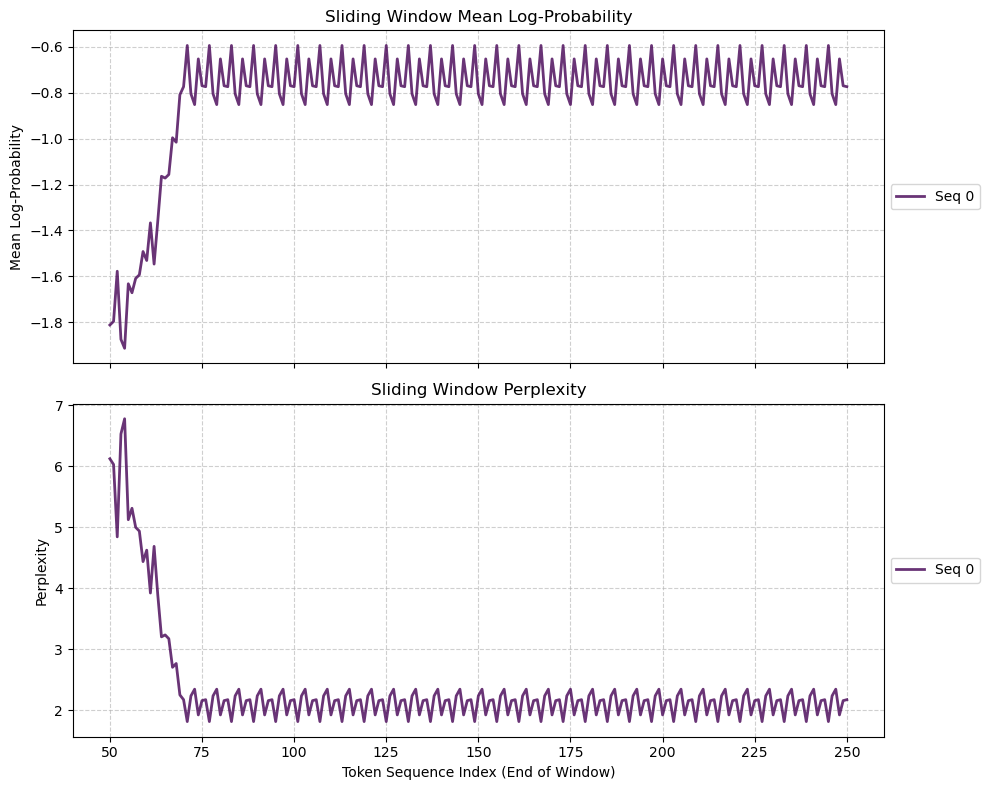

In [139]:
window_size = 51
# temperature = 1.0
# top_p = 1.0

sliding_mean_log_probs, sliding_perplexity = unfolded_sliding_window_perplexity(generation_output, model, window_size, temperature=temperature, top_p=top_p, eps=1e-15, apply_top_p=False)
# plot_sliding_window_metrics(sliding_mean_log_probs[: ,prompt_len:], sliding_perplexity[: ,prompt_len:], window_size)
plot_sliding_window_metrics(sliding_mean_log_probs[: ,:], sliding_perplexity[: ,:], window_size)

In [140]:
# Single forward pass
with torch.no_grad():
    # outputs = model(**inputs)
    outputs = model(generation_output)

In [141]:
tokenizer.decode(inputs["input_ids"][0,0], skip_special_tokens=False)

'<|begin_of_text|>'

In [142]:
# Extract Logits
# Shape: (batch_size, sequence_length, vocab_size)
logits = outputs.logits

In [143]:
# Calculate Probabilities using Softmax over the vocabulary dimension
# temperature = 1.0
# top_p = 1
logits = logits / temperature

probabilities, filtered_logits = nucleus_sampling(logits, top_p=top_p)

In [144]:
# Extract input ids
# input_ids = inputs["input_ids"]
input_ids = generation_output
chosen_probs = probabilities[0, torch.arange(probabilities.size(1)-1), input_ids[0, 1:]] # Get probabilities of the actual next tokens in the sequence
chosen_probs = chosen_probs.cpu().float().numpy()
chosen_probs = chosen_probs[prompt_len:] # Only look at generated tokens, not prompt tokens

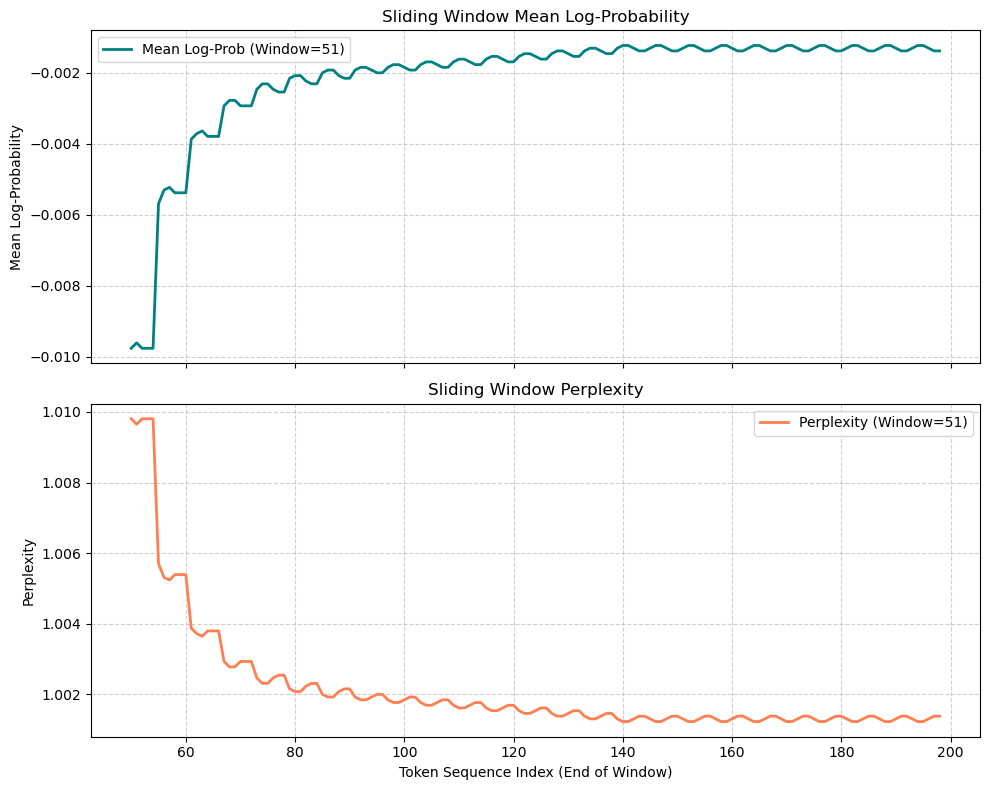

In [145]:
sliding_window = 51
moving_mean_log_probs, sliding_perplexity = compute_and_plot_sliding_window_metrics(chosen_probs, sliding_window)

In [ ]:
# print(probabilities[0,-55].cpu().float().numpy())
# for prob in probabilities[0,-55].cpu().float().numpy():
#     print(prob)
tokenizer.decode(generation_output[0, -100:-50], skip_special_tokens=False)